# Model Evaluation & Results Analysis

This notebook evaluates the performance of the LSTM baseline and DistilBERT models on the football momentum forecasting task.

We compare both models using training history, classification metrics, confusion matrices, and overall performance to understand their strengths and limitations.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report
import sys

PROJECT_ROOT = Path.cwd().parent   
sys.path.append(str(PROJECT_ROOT))

from config import *

## Loading Training Results

Load the saved training history and test predictions generated during model training. These files will be used to compare both models across multiple evaluation metrics.

In [8]:
# PATHS
DATA_PATH = BASE_DIR / "data" / "processed" / EXPERIMENT
MODELS_PATH = BASE_DIR / 'models' / EXPERIMENT
REPORTS_PATH = BASE_DIR / 'reports' / 'metrics' / EXPERIMENT
FIGURE_PATH = BASE_DIR / "reports" / "figures" / EXPERIMENT

In [9]:
# Load training results

lstm_results = pd.read_csv(MODELS_PATH / 'lstm_results.csv')
bert_results = pd.read_csv(MODELS_PATH / 'bert_results.csv')

print(lstm_results.head())
print(bert_results.head())

   epoch  train_loss  train_accuracy  train_precision  train_recall  train_f1  \
0      1    0.854355        0.529786         0.544321      0.527168  0.534043   
1      2    0.756874        0.563574         0.596741      0.560138  0.573249   
2      3    0.743027        0.567700         0.583776      0.565500  0.573058   
3      4    0.735234        0.572502         0.576688      0.569875  0.572959   
4      5    0.727109        0.575601         0.575552      0.574667  0.575103   

   val_loss  val_accuracy  val_precision  val_recall    val_f1  
0  0.771757      0.552017       0.597084    0.561587  0.568191  
1  0.760821      0.602249       0.624876    0.558665  0.499983  
2  0.735420      0.592317       0.587583    0.566164  0.551815  
3  0.738183      0.571593       0.590941    0.572263  0.579653  
4  0.729030      0.563590       0.571158    0.576529  0.566274  
   epoch  train_loss  train_accuracy  train_precision  train_recall  train_f1  \
0      1    0.675826        0.615017      

In [10]:
# Load Predictions 

lstm_preds = np.load(REPORTS_PATH / 'lstm_baseline_preds.npy')
lstm_labels = np.load(REPORTS_PATH / 'lstm_baseline_labels.npy')

bert_preds = np.load(REPORTS_PATH / 'bert_momentum_preds.npy')
bert_labels = np.load(REPORTS_PATH / 'bert_momentum_labels.npy')

print(lstm_preds , lstm_labels)
print(bert_preds, bert_labels)

[2 1 2 ... 2 1 2] [2 0 2 ... 0 0 2]
[2 0 2 ... 2 0 2] [2 0 2 ... 0 0 2]


## Training Performance

Training and validation curves provide insight into the optimization process, helping identify convergence, underfitting, or overfitting.

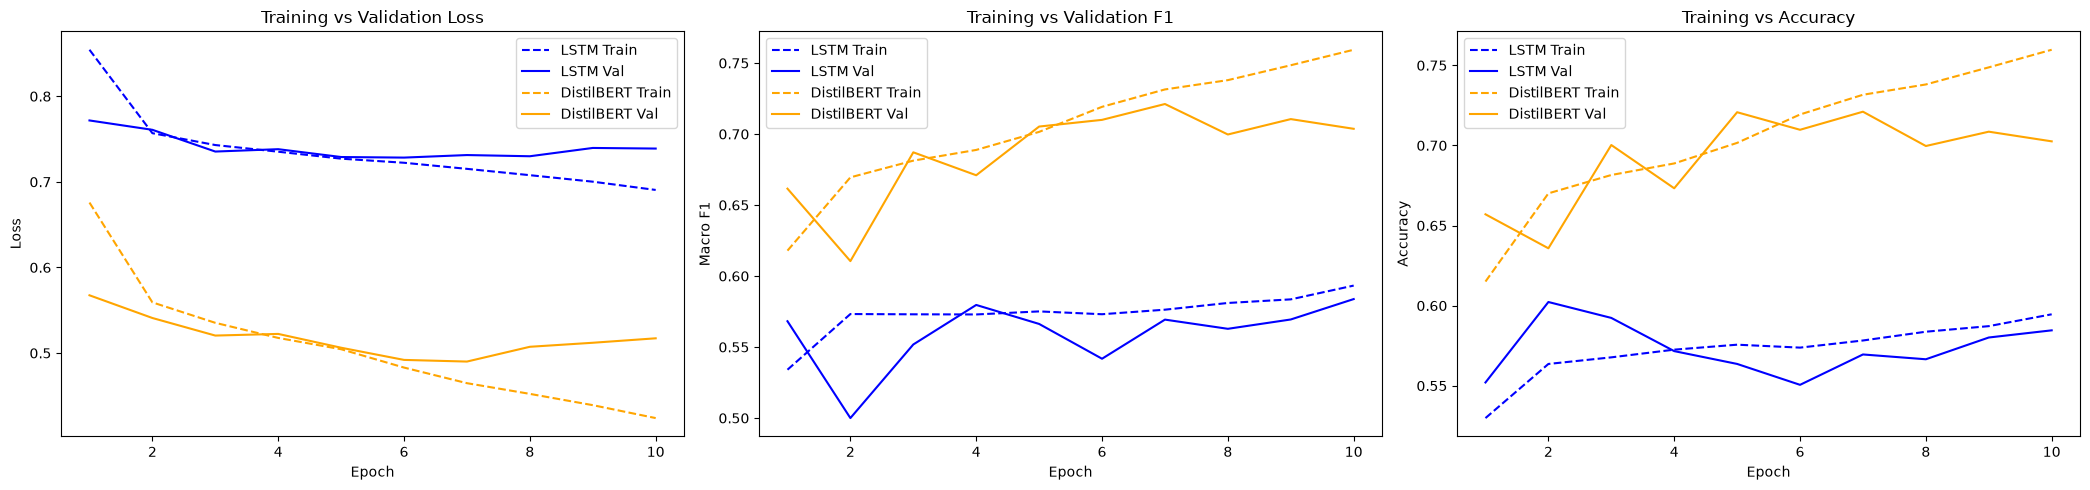

In [11]:
fig, axes = plt.subplots( 1, 3, figsize=(21,5))

# Loss curves
axes[0].plot(lstm_results['epoch'], lstm_results['train_loss'], label='LSTM Train', linestyle='--', color='blue')
axes[0].plot(lstm_results['epoch'], lstm_results['val_loss'], label='LSTM Val', color='blue')
axes[0].plot(bert_results['epoch'], bert_results['train_loss'], label='DistilBERT Train', linestyle='--',color='orange')
axes[0].plot(bert_results['epoch'], bert_results['val_loss'], label='DistilBERT Val', color='orange')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

#F1 curves
axes[1].plot(lstm_results['epoch'], lstm_results['train_f1'], label='LSTM Train', linestyle='--', color='blue')
axes[1].plot(lstm_results['epoch'], lstm_results['val_f1'], label='LSTM Val', color='blue')
axes[1].plot(bert_results['epoch'], bert_results['train_f1'], label='DistilBERT Train', linestyle='--', color='orange')
axes[1].plot(bert_results['epoch'], bert_results['val_f1'], label='DistilBERT Val', color='orange')
axes[1].set_title('Training vs Validation F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Macro F1')
axes[1].legend()

# Accuracy curves
axes[2].plot(lstm_results['epoch'], lstm_results['train_accuracy'], label='LSTM Train', linestyle='--', color='blue')
axes[2].plot(lstm_results['epoch'], lstm_results['val_accuracy'], label='LSTM Val', color='blue')
axes[2].plot(bert_results['epoch'], bert_results['train_accuracy'], label='DistilBERT Train', linestyle='--', color='orange')
axes[2].plot(bert_results['epoch'], bert_results['val_accuracy'], label='DistilBERT Val', color='orange')
axes[2].set_title('Training vs Accuracy')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].legend()

plt.tight_layout()
plt.savefig(FIGURE_PATH / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

We first inspect the training dynamics to verify that both models converge and generalize without significant overfitting.

## Classification Performance

Beyond overall accuracy, we compare precision, recall, and F1-score to evaluate how well each model predicts all three momentum classes.

In [12]:
lstm_report = classification_report(
        lstm_labels, 
        lstm_preds, 
        target_names=CLASS_NAMES,
        output_dict=True
        )

bert_report = classification_report(
    bert_labels,
    bert_preds,
    target_names=CLASS_NAMES,
    output_dict=True
)

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Macro F1', 'Weighted F1'],
    'LSTM': [
        lstm_report['accuracy'],
        lstm_report['macro avg']['f1-score'],
        lstm_report['weighted avg']['f1-score']
    ],
    'DistilBERT': [
        bert_report['accuracy'],
        bert_report['macro avg']['f1-score'],
        bert_report['weighted avg']['f1-score']
    ]
})


print(comparison.round(3))

        Metric   LSTM  DistilBERT
0     Accuracy  0.536       0.720
1     Macro F1  0.539       0.722
2  Weighted F1  0.525       0.721


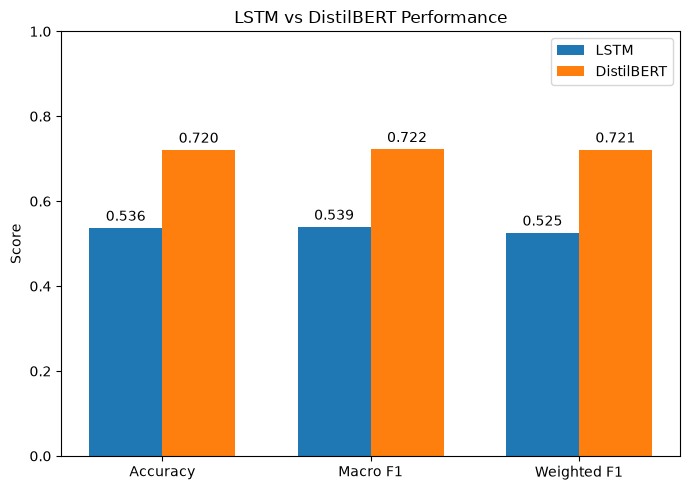

In [13]:
# Bar chart for model comparison
x = np.arange(len(comparison["Metric"]))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    x - width/2,
    comparison["LSTM"],
    width,
    label="LSTM"
)

ax.bar(
    x + width/2,
    comparison["DistilBERT"],
    width,
    label="DistilBERT"
)

ax.set_xticks(x)
ax.set_xticklabels(comparison["Metric"])

ax.set_ylabel("Score")
ax.set_title("LSTM vs DistilBERT Performance")
ax.set_ylim(0, 1)

ax.legend()

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.savefig( FIGURE_PATH / 'model_performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

DistilBERT consistently outperforms the LSTM baseline across all aggregate evaluation metrics, indicating that contextual transformer embeddings capture football commentary more effectively than static word embeddings.

## Evaluation Metrics

Accuracy provides an overall measure of classification performance, while the F1-score balances precision and recall.

Although both **Macro F1** and **Weighted F1** are reported, **Macro F1** is emphasized throughout this project because it assigns equal importance to all three momentum classes. Weighted F1 places greater emphasis on classes with more samples and can therefore mask weaker performance on minority or more challenging classes.

The per-class analysis below illustrates why Macro F1 is particularly informative for this task.

## Per-Class Performance

Overall evaluation metrics summarize model quality, but they can hide differences in performance across individual momentum classes.

To better understand each model's strengths and weaknesses, we compare the Precision, Recall, and F1-score for each momentum class separately.

In [14]:
# Per Class Dataframe
per_class = pd.DataFrame({
    "Class": CLASS_NAMES,

    "LSTM Precision": [
        lstm_report[c]["precision"] for c in CLASS_NAMES
    ],
    "DistilBERT Precision": [
        bert_report[c]["precision"] for c in CLASS_NAMES
    ],

    "LSTM Recall": [
        lstm_report[c]["recall"] for c in CLASS_NAMES
    ],
    "DistilBERT Recall": [
        bert_report[c]["recall"] for c in CLASS_NAMES
    ],

    "LSTM F1": [
        lstm_report[c]["f1-score"] for c in CLASS_NAMES
    ],
    "DistilBERT F1": [
        bert_report[c]["f1-score"] for c in CLASS_NAMES
    ]
})

display(per_class.round(3))


,Class,LSTM Precision,DistilBERT Precision,LSTM Recall,DistilBERT Recall,LSTM F1,DistilBERT F1
0,Home Dominant,0.490,0.697,0.231,0.602,0.314,0.646
1,Away Dominant,0.387,0.553,0.738,0.646,0.508,0.596
2,Balanced,0.883,0.917,0.722,0.929,0.795,0.923


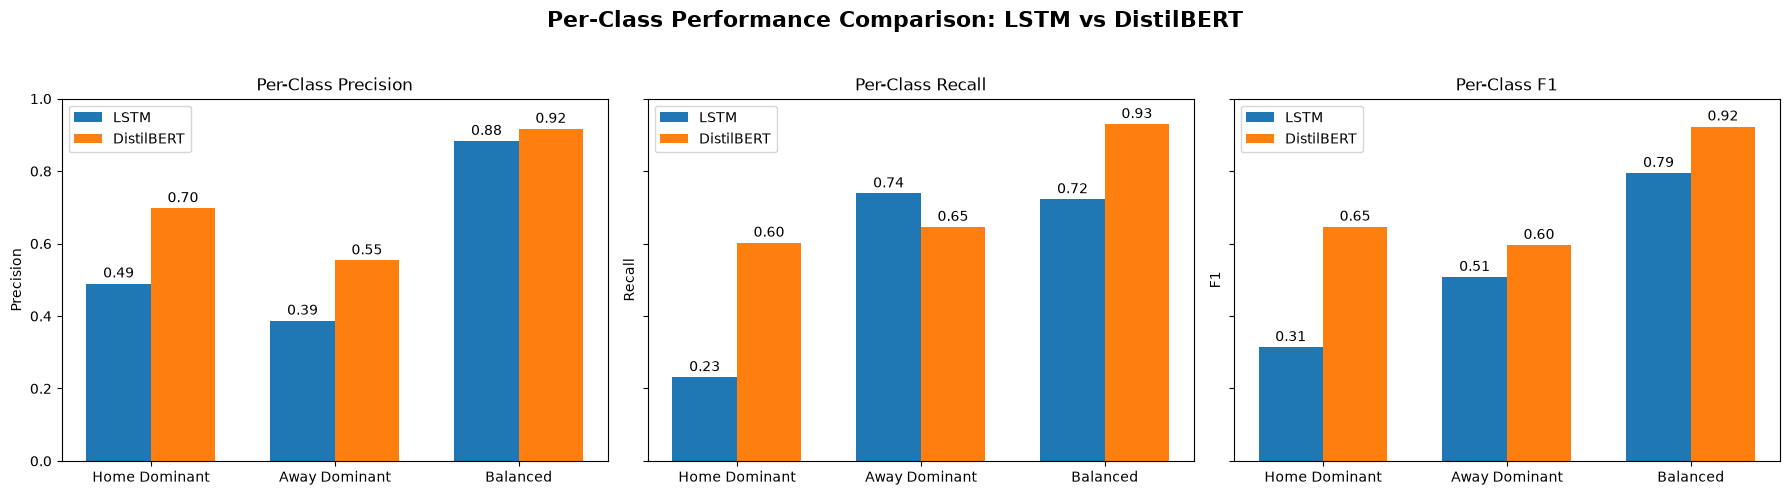

In [15]:
# Bar chart per class
fig, axes = plt.subplots(1, 3, figsize=(18,5), sharey=True)

x = np.arange(len(CLASS_NAMES))
width = 0.35

# Precision
axes[0].bar(
    x-width/2,
    per_class["LSTM Precision"],
    width,
    label="LSTM"
)
axes[0].bar(
    x+width/2,
    per_class["DistilBERT Precision"],
    width,
    label="DistilBERT"
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(CLASS_NAMES)
axes[0].set_ylim(0,1)
axes[0].set_ylabel("Precision")
axes[0].set_title("Per-Class Precision")
axes[0].legend()

# Recall
axes[1].bar(
    x-width/2,
    per_class["LSTM Recall"],
    width,
    label="LSTM"
)
axes[1].bar(
    x+width/2,
    per_class["DistilBERT Recall"],
    width,
    label="DistilBERT"
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(CLASS_NAMES)
axes[1].set_ylabel("Recall")
axes[1].set_title("Per-Class Recall")
axes[1].legend()

# F1
axes[2].bar(
    x-width/2,
    per_class["LSTM F1"],
    width,
    label="LSTM"
)
axes[2].bar(
    x+width/2,
    per_class["DistilBERT F1"],
    width,
    label="DistilBERT"
)
axes[2].set_xticks(x)
axes[2].set_xticklabels(CLASS_NAMES)
axes[2].set_ylabel("F1")
axes[2].set_title("Per-Class F1")
axes[2].legend()

for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=2)

fig.suptitle(
    "Per-Class Performance Comparison: LSTM vs DistilBERT",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig( FIGURE_PATH / 'per_class_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations

- DistilBERT outperforms the LSTM baseline across all three momentum classes.
- The largest improvement is observed for the **Home Dominant** class, indicating that contextual transformer embeddings better capture attacking momentum from live commentary.
- Both models achieve their highest performance on the **Balanced** class, suggesting that neutral match states are easier to identify than transitions into attacking phases.
- Despite the improvements, distinguishing between **Home Dominant** and **Away Dominant** remains challenging due to the subjective nature of football momentum.

## Confusion Matrix Analysis

Confusion matrices illustrate where each model makes mistakes. This helps identify whether errors occur between genuinely similar momentum states or between completely opposite classes.

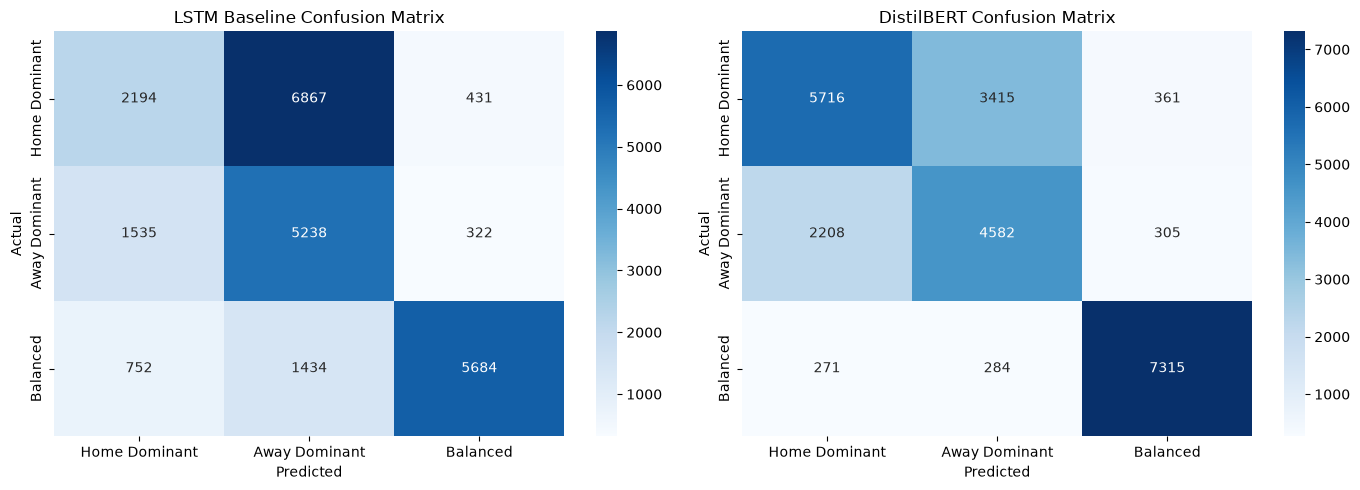

In [16]:
# Confusion Matrix

fig, axes = plt.subplots(1, 2, figsize=(14,5))

for ax, preds, labels, title in zip(
    axes,
    [lstm_preds, bert_preds],
    [lstm_labels, bert_labels],
    ['LSTM Baseline', 'DistilBERT']
):
    cm = confusion_matrix(labels, preds)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        ax=ax
    )
    ax.set_title(f'{title} Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig( FIGURE_PATH / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

The confusion matrix reveals that **Balanced** is the easiest class for the model to identify, achieving the highest recall and F1-score.

Most prediction errors occur between **Home Dominant** and **Away Dominant**, indicating that the model can reliably detect the presence of momentum but often struggles to determine which team holds the stronger advantage. In contrast, relatively few predictions confuse either dominant class with **Balanced**, suggesting that the model effectively distinguishes balanced phases of play from periods of sustained pressure.

## Error Analysis

To better understand the limitations of the DistilBERT model, we inspect prediction distributions, common error types, and representative misclassified examples.

Before inspecting individual errors, we compare the distribution of predicted classes with the ground-truth labels.

The predicted class frequencies closely match the dataset distribution, indicating that the model is not strongly biased toward any single momentum class. Instead, the majority of prediction errors arise from distinguishing the direction of momentum (Home vs Away) rather than systematically over-predicting one class.

In [ ]:
test_df = pd.read_csv( DATA_PATH / 'test.csv')

distribution = pd.DataFrame({
    "True": test_df["label"].value_counts(normalize=True).sort_index(),
    "Predicted": pd.Series(bert_preds).value_counts(normalize=True).sort_index()
})

distribution

,True,Predicted
0,0.388110,0.335078
1,0.290101,0.338594
2,0.321789,0.326328


In [ ]:
# Making a error df
error_df = test_df.copy()

error_df["True Label"] = bert_labels
error_df["Predicted Label"] = bert_preds

error_df["Correct"] = (
    error_df["True Label"] ==
    error_df["Predicted Label"]
)

# Errors -> everything not correct
errors = error_df[~error_df["Correct"]].copy()

In [ ]:
# Change to label names
label_map = {
    0: "Home Dominant",
    1: "Away Dominant",
    2: "Balanced"
}

# Apply mapping
errors["True"] = errors["True Label"].map(label_map)
errors["Predicted"] = errors["Predicted Label"].map(label_map)

In [ ]:
# Display most error types by the model
errors["Error Type"] = (
    errors["True"] +
    " → " +
    errors["Predicted"]
)
errors["Error Type"].value_counts()

Error Type
Home Dominant → Away Dominant    3415
Away Dominant → Home Dominant    2208
Home Dominant → Balanced          361
Away Dominant → Balanced          305
Balanced → Away Dominant          284
Balanced → Home Dominant          271
Name: count, dtype: int64

The examples below are selected from the most frequent misclassification categories identified in the error distribution. They illustrate the types of match situations that remain challenging for the model.

In [ ]:
# Misclassified Examples
home_to_away = errors[
    (errors["True"] == "Home Dominant") &
    (errors["Predicted"] == "Away Dominant")
].sample(3, random_state=42)

away_to_home = errors[
    (errors["True"] == "Away Dominant") &
    (errors["Predicted"] == "Home Dominant")
].sample(3, random_state=42)

balanced_examples = errors[
    errors["True"] == "Balanced"
].sample(2, random_state=42)

In [71]:
def print_examples(df, title):
    print(f"\n{'='*80}")
    print(title)
    print(f"{'='*80}")

    for i, (_, row) in enumerate(df.iterrows(), start=1):
        print(f"Example {i}")
        print(f"Text      : {row['text']}")
        print(f"True      : {row['True']}")
        print(f"Predicted : {row['Predicted']}")
        print("-" * 100)

print_examples(home_to_away, "Home Dominant → Away Dominant")
print_examples(away_to_home, "Away Dominant → Home Dominant")
print_examples(balanced_examples, "Balanced Misclassified")


Home Dominant → Away Dominant
Example 1
Text      : Attempt missed. Lionel Messi (Barcelona) right footed shot from the right side of the box is close, but misses to the right. Assisted by Neymar.
True      : Home Dominant
Predicted : Away Dominant
----------------------------------------------------------------------------------------------------
Example 2
Text      : Hand ball by Franco VA¡zquez (Palermo). Franco VA¡zquez (Palermo) is shown the yellow card for hand ball. Attempt saved. Simone Verdi (Empoli) right footed shot from outside the box is saved in the top centre of the goal. Assisted by Manuel Pucciarelli. Corner,  Empoli. Conceded by Stefano Sorrentino. Attempt blocked. Matias Vecino (Empoli) right footed shot from outside the box is blocked. Corner,  Empoli. Conceded by Francesco Bolzoni. Claudio Terzi (Palermo) wins a free kick in the defensive half. Foul by Manuel Pucciarelli (Empoli). Foul by Sinisa Andjelkovic (Palermo). Simone Verdi (Empoli) wins a free kick in the 

### Observations

Inspection of the confusion matrix and misclassified examples reveals several recurring patterns:

- The DistilBERT model identifies **Balanced** momentum states with high reliability, achieving over 92% recall for this class.
- Most prediction errors occur between **Home Dominant** and **Away Dominant**, indicating that the model can often detect the presence of momentum but struggles to determine which team has the stronger advantage.
- Many misclassified examples contain attacking actions from both teams or routine football events such as fouls, substitutions, and offsides. These situations provide limited contextual evidence for assigning a clear momentum direction.
- Since the target labels are generated using a heuristic momentum scoring function rather than human annotations, some prediction errors may also reflect ambiguity in the generated labels rather than incorrect model behaviour.

## Model Comparison

A side-by-side comparison summarizes the overall performance of both models across the evaluation metrics.

In [11]:
# Summary Comparison Table

summary = pd.DataFrame({
    'Model': ['LSTM Baseline', 'DistilBERT'],
    'Test Accuracy': [0.54, 0.72],
    'Macro F1': [0.54, 0.72],
    'Home Dominant F1': [0.31, 0.65],
    'Away Dominant F1': [0.51, 0.60],
    'Balanced F1': [0.79, 0.92]
})
summary.set_index('Model', inplace=True)
print(summary)

               Test Accuracy  Macro F1  Home Dominant F1  Away Dominant F1  \
Model                                                                        
LSTM Baseline           0.54      0.54              0.31              0.51   
DistilBERT              0.72      0.72              0.65              0.60   

               Balanced F1  
Model                       
LSTM Baseline         0.79  
DistilBERT            0.92  


## Discussion

DistilBERT consistently outperformed the LSTM baseline across all evaluation metrics. The transformer architecture benefits from contextual language representations, allowing it to capture richer relationships between football events than the sequence-based LSTM model.

Despite the improvement, football momentum remains a challenging prediction task because momentum is an abstract concept rather than a directly observable variable. Most prediction errors occur when distinguishing the direction of momentum (Home Dominant vs Away Dominant), suggesting that identifying which team holds the advantage is considerably more difficult than recognizing balanced phases of play.

## Conclusions

This project demonstrates that transformer-based language models provide a substantial improvement over traditional sequence models for football momentum prediction from live commentary.

Key findings:

- DistilBERT achieved the strongest overall performance, improving test accuracy from 54% to 72% and increasing the macro F1-score from 0.54 to 0.72 compared with the LSTM baseline.
- The LSTM provides a strong baseline while requiring fewer computational resources.
- Football momentum is inherently subjective, making perfect classification unrealistic.
- The trained DistilBERT model will be used as the prediction engine for the interactive football momentum dashboard developed in the next stage of the project.